In [3]:
# predict_kpt_duration_pipeline.py

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu
df = pd.read_csv("cleaned_orders_with_2_items.csv")


📦 Kích thước dữ liệu: (7953, 30)

🧱 Các cột trong dữ liệu:
Index(['Restaurant ID', 'Restaurant name', 'Subzone', 'City', 'Order ID',
       'Order Placed At', 'Order Status', 'Delivery', 'Distance',
       'Items in order', 'Instructions', 'Discount construct', 'Bill subtotal',
       'Packaging charges', 'Restaurant discount (Promo)',
       'Restaurant discount (Flat offs, Freebies & others)', 'Gold discount',
       'Brand pack discount', 'Total', 'Rating', 'Review',
       'Cancellation / Rejection reason',
       'Restaurant compensation (Cancellation)',
       'Restaurant penalty (Rejection)', 'KPT duration (minutes)',
       'Rider wait time (minutes)', 'Order Ready Marked',
       'Customer complaint tag', 'Customer ID', 'Order Item Count'],
      dtype='object')

🔍 Kiểu dữ liệu:
Restaurant ID                                           int64
Restaurant name                                        object
Subzone                                                object
City           

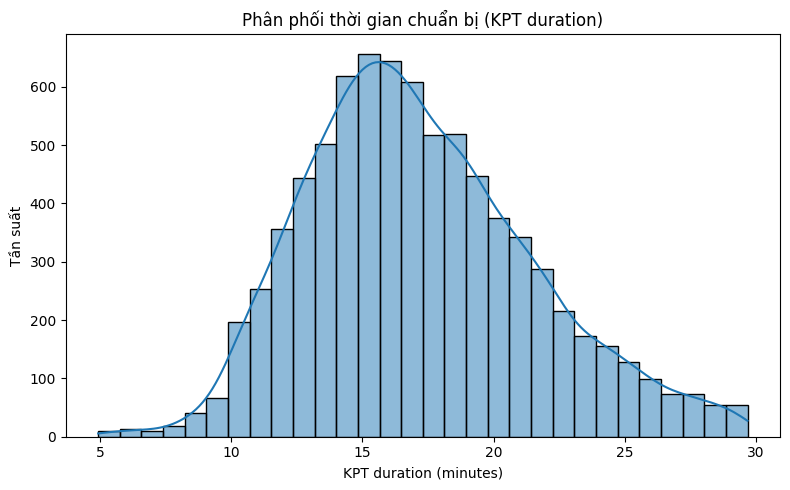


🏪 Top 10 nhà hàng phổ biến:
Restaurant name
Aura Pizzas             5614
Swaad                   2231
Dilli Burger Adda         67
Tandoori Junction         32
Masala Junction            5
The Chicken Junction       4
Name: count, dtype: int64


/var/folders/93/jzhc9xv925g12nywcpx4b7b80000gn/T/ipykernel_90331/1682909086.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Order Placed At"] = pd.to_datetime(df["Order Placed At"])


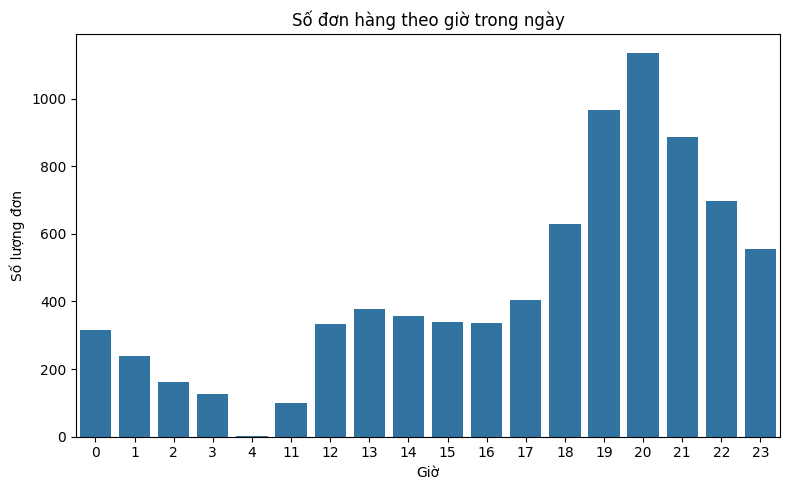

In [ ]:

# Tổng quan dữ liệu
print("📦 Kích thước dữ liệu:", df.shape)
print("\n🧱 Các cột trong dữ liệu:")
print(df.columns)

print("\n🔍 Kiểu dữ liệu:")
print(df.dtypes)

print("\n🧾 Một vài dòng dữ liệu đầu tiên:")
print(df.head())

# Thống kê mô tả cho KPT duration
print("\n📊 Thống kê KPT duration (minutes):")
print(df["KPT duration (minutes)"].describe())

# Phân phối KPT
plt.figure(figsize=(8, 5))
sns.histplot(df["KPT duration (minutes)"], bins=30, kde=True)
plt.title("Phân phối thời gian chuẩn bị (KPT duration)")
plt.xlabel("KPT duration (minutes)")
plt.ylabel("Tần suất")
plt.tight_layout()
plt.show()

# Top 10 nhà hàng có nhiều đơn nhất
print("\n🏪 Top 10 nhà hàng phổ biến:")
print(df["Restaurant name"].value_counts().head(10))

# Trích xuất giờ từ cột Order placed at
df["Order Placed At"] = pd.to_datetime(df["Order Placed At"], format="%I:%M %p, %B %d %Y")
df["Hour"] = df["Order Placed At"].dt.hour

# Thống kê theo giờ đặt đơn
plt.figure(figsize=(8, 5))
sns.countplot(x="Hour", data=df)
plt.title("Số đơn hàng theo giờ trong ngày")
plt.xlabel("Giờ")
plt.ylabel("Số lượng đơn")
plt.tight_layout()
plt.show()
